<a href="https://colab.research.google.com/github/abhishek18-blog/DataScience-and-ML/blob/main/fishcnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications
import os

# 1. Download dataset
print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("subirbiswas19/freshwater-fish-disease-aquaculture-in-south-asia")
image_dir = os.path.join(dataset_path, 'Freshwater Fish Disease Aquaculture in south asia', 'Train')

# 2. Hyperparameters
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 30

# 3. Data Loading
train_dataset = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

# 4. Build Advanced Model (EfficientNetB0)
base_model = applications.EfficientNetB0(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
# Unfreeze the top 20 layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

# 5. Compile with a slightly lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Callbacks: EarlyStopping + ReduceLROnPlateau
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 7. Train
print("Starting advanced training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)

model.save("improved_fish_disease_model.h5")
print("Improved model saved!")

100%|██████████| 24.8M/24.8M [00:00<00:00, 140MB/s] 

Extracting files...


Found 1747 files belonging to 7 classes.
Using 1398 files for training.
Found 1747 files belonging to 7 classes.
Using 349 files for validation.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting advanced training...
Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 217ms/step - accuracy: 0.3004 - loss: 1.9702 - val_accuracy: 0.5215 - val_loss: 1.4636 - learning_rate: 1.0000e-04
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.5415 - loss: 1.2889 - val_accuracy: 0.6877 - val_loss: 1.1053 - learning_rate: 1.0000e-04
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.6724 - loss: 0.9695 - val_accuracy: 0.7708 - val_loss: 0.8715 - learning_rate: 1.0000e-04
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.7411 - loss: 0.7915 - val_accuracy: 0.8109 - val_loss: 0.7140 - learning_rate: 1.0000e-04
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.7790 - loss: 0.6540 - val_accuracy: 0.8424 - val_loss: 0.5816 - learning_rate: 1.00

Improved model saved!


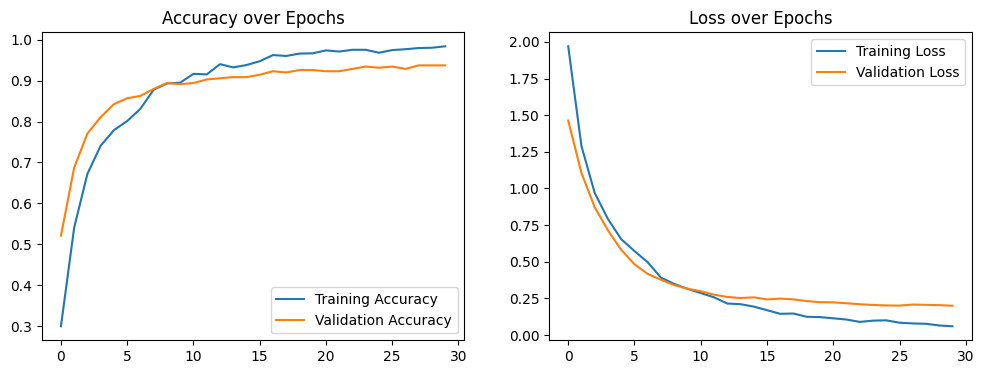

--- Improved Classification Report ---
                                   precision    recall  f1-score   support

            Bacterial Red disease       0.90      0.86      0.88        44
Bacterial diseases - Aeromoniasis       0.98      0.83      0.90        60
           Bacterial gill disease       0.94      0.90      0.92        49
   Fungal diseases Saprolegniasis       0.78      0.90      0.84        52
                     Healthy Fish       0.81      0.98      0.89        53
               Parasitic diseases       0.92      0.76      0.83        46
Viral diseases White tail disease       0.77      0.80      0.78        45

                         accuracy                           0.87       349
                        macro avg       0.87      0.86      0.86       349
                     weighted avg       0.87      0.87      0.87       349



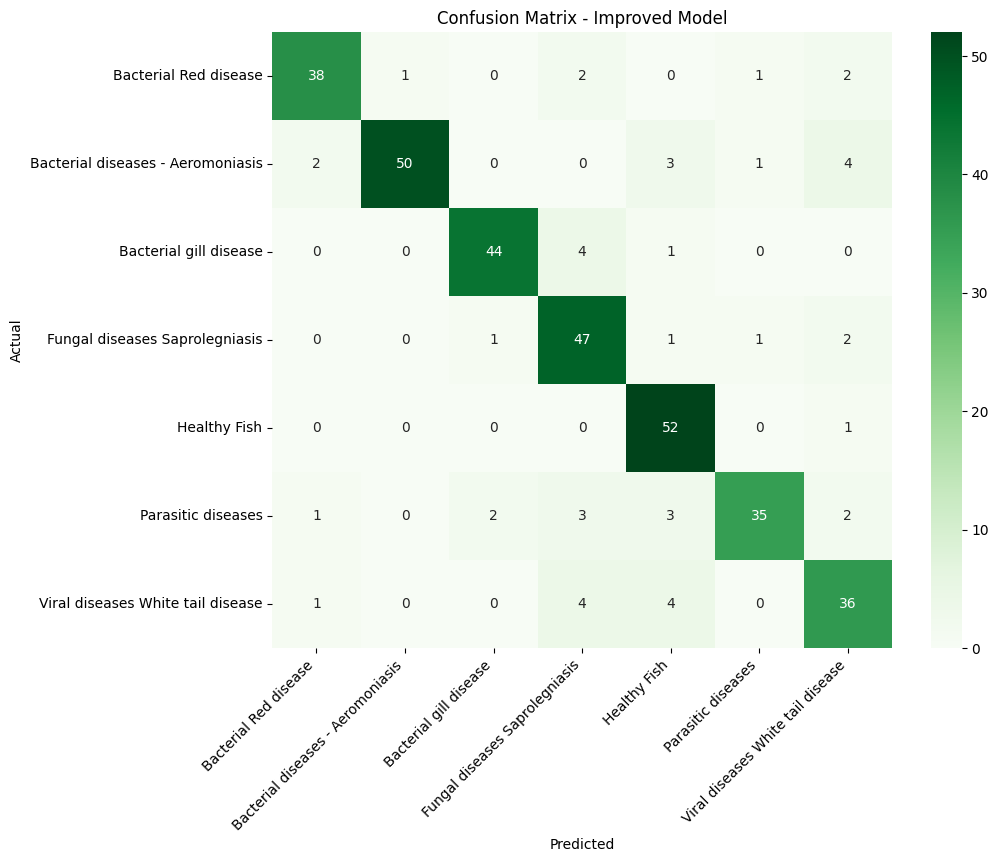

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Check if 'history' exists from training
try:
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.show()
except NameError:
    print("Error: 'history' variable not found. Please ensure you have completed the training in cell PkdIBzCedVi6 before running this evaluation.")

# 2. Detailed Evaluation
# Use 'model' from the training cell if it exists
try:
    y_true = []
    y_pred = []
    for images, labels in val_dataset:
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))

    print("--- Improved Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # 3. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Improved Model')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.show()
except NameError as e:
    print(f"Error: {e}. Please ensure the model and datasets are loaded.")

Loading unseen test data...
Found 697 files belonging to 7 classes.

--- Final Model Evaluation ---
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.9426 - loss: 0.1641
Final Test Loss: 0.1641
Final Test Accuracy: 94.26%

Generating detailed metrics...
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step

--- Classification Report (Test Set) ---
                                   precision    recall  f1-score   support

            Bacterial Red disease       0.98      0.95      0.96       100
Bacterial diseases - Aeromoniasis       0.99      0.94      0.96       100
           Bacterial gill disease       0.98      0.90      0.94       100
   Fungal diseases Saprolegniasis       0.89      0.98      0.93       100
                     Healthy Fish       0.89      0.98      0.93       100
               Parasitic diseases       0.98      0.94      0.96       100
Viral diseases White tail disease       0.91      0.91      0.91        97

                         accuracy                        

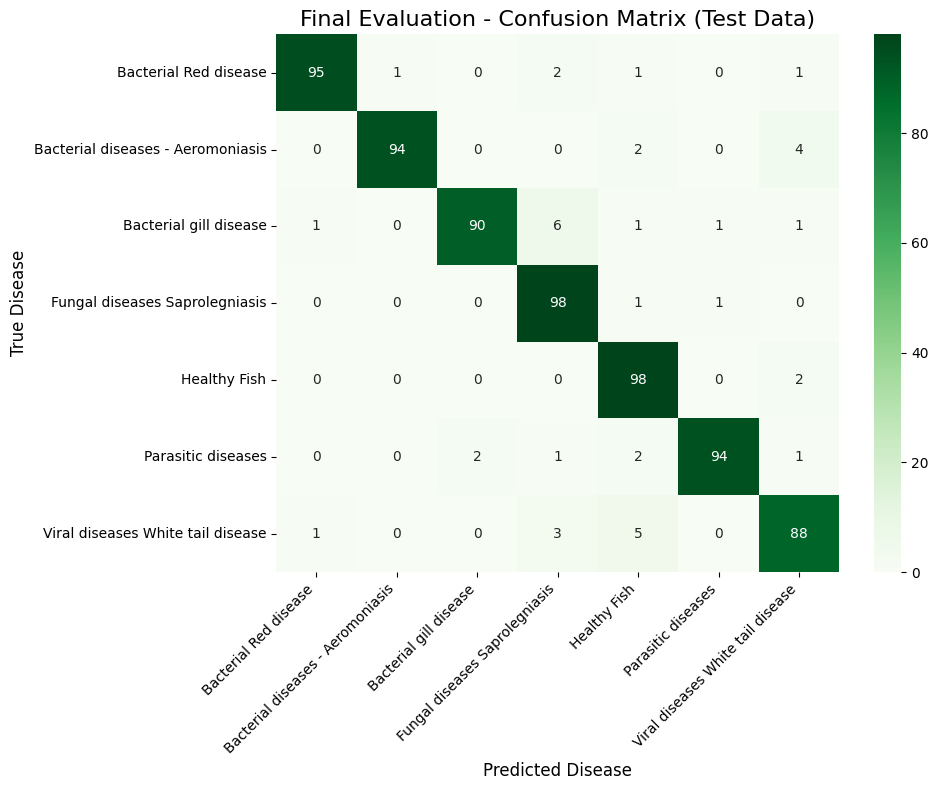

In [ ]:
import tensorflow as tf
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Saved Model
model_path = "improved_fish_disease_model.h5"
model = tf.keras.models.load_model(model_path)

# 2. Define the path to the Test folder
# Make sure dataset_path is still defined from your kagglehub download
test_dir = os.path.join(dataset_path, 'Freshwater Fish Disease Aquaculture in south asia', 'Test')

# 3. Load the Test Dataset
print("Loading unseen test data...")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False # CRITICAL: Must be False so predictions align with true labels!
)

class_names = test_dataset.class_names

# 4. Standard Evaluation (Loss and Accuracy)
print("\n--- Final Model Evaluation ---")
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%\n")

# 5. Extract True Labels and Generate Predictions
print("Generating detailed metrics...")
# Extract all true labels from the dataset
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_true_indices = np.argmax(y_true, axis=1)

# Generate predictions for the entire test set
predictions = model.predict(test_dataset)
y_pred_indices = np.argmax(predictions, axis=1)

# 6. Print Classification Report
print("\n--- Classification Report (Test Set) ---")
print(classification_report(y_true_indices, y_pred_indices, target_names=class_names))

# 7. Plot Final Confusion Matrix
cm = confusion_matrix(y_true_indices, y_pred_indices)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Final Evaluation - Confusion Matrix (Test Data)', fontsize=16)
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Saving fish12.jpg to fish12.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


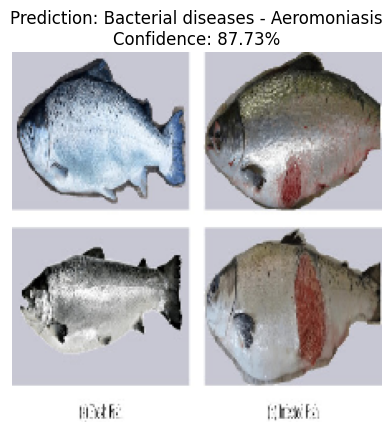

The fish in the image is most likely: Bacterial diseases - Aeromoniasis (87.73% confidence)


In [ ]:
from google.colab import files
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the model if not in memory
try:
    model
except NameError:
    model = tf.keras.models.load_model('improved_fish_disease_model.h5')

# 2. Upload the file
uploaded = files.upload()

for fn in uploaded.keys():
    # 3. Preprocess the image
    img_path = fn
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create batch axis
    # EfficientNetB0 usually expects [0, 255] for the Keras layer if rescaling isn't in the model,
    # but we built the model with the base_model inside which handles normalization internally or via Sequential layers.

    # 4. Predict
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = 100 * np.max(predictions[0])

    # 5. Display Result
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    print(f"The fish in the image is most likely: {predicted_class} ({confidence:.2f}% confidence)")